In [94]:
import openrouteservice
import numpy
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from shapely import geometry
from openrouteservice import client
import plotly.express as px
import time
import geopy.distance
import plotly.graph_objects as go

**Import the route class**

In [2]:
from Routing_Class import route

**Initialize the route**

In [3]:
test = route()

**Generate some Data for a patient, responders, and aeds**

In [4]:
# simulated patient
patient = (4.703659, 50.874214) # 4.687876287543574, 50.87842282066306

# Generate 80 random lat and long
N=40
lon = np.random.uniform(4.69,4.71,N)
lat = np.random.uniform(50.85,50.88,N)

# Create dataframe from the numpy arrays
responder = pd.DataFrame({'longitude':lon, 'latitude':lat})

N=10
lon = np.random.uniform(4.69,4.71,N)
lat = np.random.uniform(50.85,50.88,N)

# Create geodataframe from numpy arrays
aed = pd.DataFrame({'longitude':lon, 'latitude':lat})

**Find the closest responders and aeds**

In [5]:
Client_ors_test = openrouteservice.Client(key='5b3ce3597851110001cf624802e069d6633748a5ae4e9842334f1dc2')

In [7]:
isochrones_parameters = {
        'locations': [patient],
        'profile': "foot-walking",
        'range_type': 'time',
        'range': [600] # 10 minutes away (600 seconds)
        }

In [8]:
asd = Client_ors_test.isochrones(**isochrones_parameters)

In [9]:
asd

{'type': 'FeatureCollection',
 'bbox': [4.694265, 50.868172, 4.712657, 50.879394],
 'features': [{'type': 'Feature',
   'properties': {'group_index': 0,
    'value': 600.0,
    'center': [4.703658296380895, 50.87421540995241]},
   'geometry': {'coordinates': [[[4.694377, 50.875101],
      [4.694265, 50.874602],
      [4.694863, 50.872152],
      [4.696619, 50.870675],
      [4.699205, 50.868419],
      [4.699304, 50.868343],
      [4.699622, 50.868179],
      [4.699669, 50.868172],
      [4.70251, 50.868185],
      [4.708457, 50.8684],
      [4.708542, 50.86842],
      [4.70895, 50.868688],
      [4.710352, 50.869684],
      [4.710401, 50.869748],
      [4.712248, 50.872341],
      [4.71241, 50.872663],
      [4.712657, 50.874261],
      [4.712188, 50.875907],
      [4.711458, 50.878102],
      [4.709878, 50.879169],
      [4.708529, 50.879394],
      [4.704163, 50.87937],
      [4.703216, 50.879373],
      [4.702307, 50.879379],
      [4.700643, 50.879383],
      [4.700304, 50.87927],

In [9]:
asd['features'][0]['geometry']['coordinates'][0]

[[4.694377, 50.875101],
 [4.694265, 50.874602],
 [4.694863, 50.872152],
 [4.696619, 50.870675],
 [4.699205, 50.868419],
 [4.699304, 50.868343],
 [4.699622, 50.868179],
 [4.699669, 50.868172],
 [4.70251, 50.868185],
 [4.708457, 50.8684],
 [4.708542, 50.86842],
 [4.70895, 50.868688],
 [4.710352, 50.869684],
 [4.710401, 50.869748],
 [4.712248, 50.872341],
 [4.71241, 50.872663],
 [4.712657, 50.874261],
 [4.712188, 50.875907],
 [4.711458, 50.878102],
 [4.709878, 50.879169],
 [4.708529, 50.879394],
 [4.704163, 50.87937],
 [4.703216, 50.879373],
 [4.702307, 50.879379],
 [4.700643, 50.879383],
 [4.700304, 50.87927],
 [4.697689, 50.878216],
 [4.69697, 50.877863],
 [4.694793, 50.876791],
 [4.694377, 50.875101]]

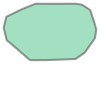

In [10]:
geometry.Polygon(asd['features'][0]['geometry']['coordinates'][0])

In [ ]:
import folium
m = folium.Map(location=[50.874214, 4.703659], tiles='cartodbpositron', zoom_start=13)

# Some coordinate in Leuven
coordinate = [[4.687876287543574, 50.87842282066306]]

isochrones_parameters = {
        'locations': [patient],
        'profile': "foot-walking",
        'range_type': 'time',
        'range': [600] # 10 minutes away (600 seconds)
        }

iso = Client_ors_test.isochrones(**isochrones_parameters)

# Also create a Popup with Population count within isochrones
for isochrone in iso['features']:
    folium.Polygon(locations=[list(reversed(coord)) for coord in isochrone['geometry']['coordinates'][0]],
                  fill='00ff00').add_to(m)
    
m

In [12]:
poly = geometry.Polygon(asd['features'][0]['geometry']['coordinates'][0])
d = {'geometry': [poly]}
gdf = gpd.GeoDataFrame(d)

In [13]:
df = pd.DataFrame({'lat':responder.loc[:,"latitude"], 'lon':responder.loc[:,"longitude"]})

In [14]:
df['coords'] = list(zip(df['lon'],df['lat']))

In [15]:
df['coords'] = df['coords'].apply(geometry.Point)

In [16]:
points = gpd.GeoDataFrame(df, geometry='coords', crs=gdf.crs)

In [17]:
points = list(points['coords'])

In [18]:
points_inside_polygon = []
# For loop to iterate through all possible responders.
for point in points:
    if point.within(gdf['geometry'][0]):
        points_inside_polygon.append(point)

In [19]:
coordinate_tuples = [(point.x, point.y) for point in points_inside_polygon]

In [20]:
coordinate_tuples

[(4.696409064881914, 50.874626525454595),
 (4.705419320532887, 50.87155222640364),
 (4.69518254560888, 50.87189131997917),
 (4.704402942877348, 50.87009627697156)]

In [21]:
close_resp = test.closest_location(patient, responder)
close_resp

[(4.696409064881914, 50.874626525454595),
 (4.705419320532887, 50.87155222640364),
 (4.69518254560888, 50.87189131997917),
 (4.704402942877348, 50.87009627697156)]

In [22]:
close_aed = test.closest_location(patient, aed)
close_aed

[(4.697708434884579, 50.87275692062988),
 (4.696264079203804, 50.873368267275225)]

Duration to patients

In [23]:
asd2 = test.duration_to_Patient(patient, responder)

In [24]:
asd2

,longitude,latitude,duration_direct
0,4.696319,50.874618,512.45
1,4.704965,50.871737,275.91
2,4.695205,50.871830,686.53
3,4.704483,50.870141,426.73


In [25]:
x = test.closest_location(patient, responder)
x

[(4.696409064881914, 50.874626525454595),
 (4.705419320532887, 50.87155222640364),
 (4.69518254560888, 50.87189131997917),
 (4.704402942877348, 50.87009627697156)]

In [26]:
x.append(patient)

In [27]:
matrix = Client_ors_test.distance_matrix(
                    locations=x,
                    profile='foot-walking',
                    sources = list(range(len(x)-1)),
                    destinations = [len(x)-1],
                    metrics=['duration']
                )

In [28]:
matrix

{'durations': [[512.45], [275.91], [686.53], [426.73]],
 'destinations': [{'location': [4.703658, 50.874215],
   'snapped_distance': 0.16}],
 'sources': [{'location': [4.696319, 50.874618], 'snapped_distance': 6.39},
  {'location': [4.704965, 50.871737], 'snapped_distance': 37.89},
  {'location': [4.695205, 50.87183], 'snapped_distance': 6.97},
  {'location': [4.704483, 50.870141], 'snapped_distance': 7.49}],
 'metadata': {'attribution': 'openrouteservice.org | OpenStreetMap contributors',
  'service': 'matrix',
  'timestamp': 1714833062606,
  'query': {'locations': [[4.696409064881914, 50.874626525454595],
    [4.705419320532887, 50.87155222640364],
    [4.69518254560888, 50.87189131997917],
    [4.704402942877348, 50.87009627697156],
    [4.703659, 50.874214]],
   'profile': 'foot-walking',
   'responseType': 'json',
   'sources': ['0', '1', '2', '3'],
   'destinations': ['4'],
   'metrics': ['duration']},
  'engine': {'version': '8.0.0',
   'build_date': '2024-03-21T13:55:54Z',
   '

In [29]:
source = []
for i in range(len(matrix["sources"])):
    source.append([matrix['sources'][i]['location'][0], matrix['sources'][i]['location'][1],float(matrix['durations'][i][0])])

In [30]:
source

[[4.696319, 50.874618, 512.45],
 [4.704965, 50.871737, 275.91],
 [4.695205, 50.87183, 686.53],
 [4.704483, 50.870141, 426.73]]

In [31]:
df_duration = pd.DataFrame(source, columns = ['longitude', 'latitude', 'duration_direct']) 
df_duration

,longitude,latitude,duration_direct
0,4.696319,50.874618,512.45
1,4.704965,50.871737,275.91
2,4.695205,50.871830,686.53
3,4.704483,50.870141,426.73


directions

In [32]:
route = Client_ors_test.directions(coordinates=[close_resp[0], patient],
                                   profile='foot-walking',
                                   format='geojson',
                                   validate=False)

In [33]:
route.get('features')[0]['properties']['summary']['duration']

512.4

In [34]:
route.get('features')[0]['properties']['summary']['duration'] == route['features'][0]['properties']['summary']['duration']

True

In [35]:
route.get('features')[0]['geometry']['coordinates']

[[4.696319, 50.874618],
 [4.696278, 50.874786],
 [4.696375, 50.874799],
 [4.696514, 50.874811],
 [4.696529, 50.874814],
 [4.696727, 50.874938],
 [4.696749, 50.87496],
 [4.696799, 50.875004],
 [4.696803, 50.875007],
 [4.696999, 50.875142],
 [4.697071, 50.875172],
 [4.697726, 50.875267],
 [4.697932, 50.874985],
 [4.697991, 50.875005],
 [4.698023, 50.874965],
 [4.698041, 50.87497],
 [4.698015, 50.875002],
 [4.698081, 50.875023],
 [4.698161, 50.875021],
 [4.698293, 50.875013],
 [4.698581, 50.875086],
 [4.698726, 50.875066],
 [4.698886, 50.874963],
 [4.698933, 50.874932],
 [4.69899, 50.874899],
 [4.699016, 50.87481],
 [4.699061, 50.874779],
 [4.699288, 50.874742],
 [4.699261, 50.874661],
 [4.699313, 50.874635],
 [4.699518, 50.874608],
 [4.699645, 50.874592],
 [4.699674, 50.874571],
 [4.700035, 50.874538],
 [4.699965, 50.87421],
 [4.700195, 50.874159],
 [4.700589, 50.874003],
 [4.701352, 50.873623],
 [4.701902, 50.87388],
 [4.7021, 50.87396],
 [4.702376, 50.874039],
 [4.702902, 50.87419],
 [

In [36]:
route.get('features')[0]['geometry']['coordinates'] == route['features'][0]['geometry']['coordinates']

True

In [37]:
route_dict = {}
route_dict['duration'] = route.get('features')[0]['properties']['summary']['duration']
route_dict['route'] = route    # Is this really needed? puts the whole output of the API call into the column
route_dict['coordinates'] = route.get('features')[0]['geometry']['coordinates']
route_dict

{'duration': 512.4,
 'route': {'type': 'FeatureCollection',
  'bbox': [4.696278, 50.873623, 4.703658, 50.875267],
  'features': [{'bbox': [4.696278, 50.873623, 4.703658, 50.875267],
    'type': 'Feature',
    'properties': {'segments': [{'distance': 711.8,
       'duration': 512.4,
       'steps': [{'distance': 18.9,
         'duration': 13.6,
         'type': 11,
         'instruction': 'Head north',
         'name': '-',
         'way_points': [0, 1]},
        {'distance': 120.4,
         'duration': 86.7,
         'type': 1,
         'instruction': 'Turn right onto Redingenstraat',
         'name': 'Redingenstraat',
         'way_points': [1, 11]},
        {'distance': 34.5,
         'duration': 24.8,
         'type': 1,
         'instruction': 'Turn right onto Schapenstraat',
         'name': 'Schapenstraat',
         'way_points': [11, 12]},
        {'distance': 93.5,
         'duration': 67.3,
         'type': 0,
         'instruction': 'Turn left onto Wolvenpoortpad',
         '

**Show the directions function and its output**

In [38]:
direction = test.directions([close_resp[0], patient], profile = 'foot-walking')
direction

{'duration': 512.4,
 'route': {'type': 'FeatureCollection',
  'bbox': [4.696278, 50.873623, 4.703658, 50.875267],
  'features': [{'bbox': [4.696278, 50.873623, 4.703658, 50.875267],
    'type': 'Feature',
    'properties': {'segments': [{'distance': 711.8,
       'duration': 512.4,
       'steps': [{'distance': 18.9,
         'duration': 13.6,
         'type': 11,
         'instruction': 'Head north',
         'name': '-',
         'way_points': [0, 1]},
        {'distance': 120.4,
         'duration': 86.7,
         'type': 1,
         'instruction': 'Turn right onto Redingenstraat',
         'name': 'Redingenstraat',
         'way_points': [1, 11]},
        {'distance': 34.5,
         'duration': 24.8,
         'type': 1,
         'instruction': 'Turn right onto Schapenstraat',
         'name': 'Schapenstraat',
         'way_points': [11, 12]},
        {'distance': 93.5,
         'duration': 67.3,
         'type': 0,
         'instruction': 'Turn left onto Wolvenpoortpad',
         '

**This is the function finding all possible routes**

The output is a Data Frame

In [39]:
df_possible_route = test.possible_routing(patient, responder, aed, threshold = 700)
df_possible_route

,longitude,latitude,Responder_loc,Patient_lon,Patient_lat,Patient_loc,dist_patient,duration_direct,AED_coordinates,dist_AED,duration_through_AED
0,4.696409,50.874627,"(4.696409064881914, 50.874626525454595)",4.703659,50.874214,"(4.703659, 50.874214)",803.015755,5000.0,"(4.697708434884579, 50.87275692062988)",252.334466,740.5
1,4.696409,50.874627,"(4.696409064881914, 50.874626525454595)",4.703659,50.874214,"(4.703659, 50.874214)",803.015755,5000.0,"(4.702960809200467, 50.879861022354)",928.537452,5000.0
2,4.696409,50.874627,"(4.696409064881914, 50.874626525454595)",4.703659,50.874214,"(4.703659, 50.874214)",803.015755,5000.0,"(4.69537973760983, 50.86972967075774)",555.093255,1336.6
3,4.696409,50.874627,"(4.696409064881914, 50.874626525454595)",4.703659,50.874214,"(4.703659, 50.874214)",803.015755,5000.0,"(4.696264079203804, 50.873368267275225)",140.519168,671.9
4,4.705419,50.871552,"(4.705419320532887, 50.87155222640364)",4.703659,50.874214,"(4.703659, 50.874214)",353.699840,275.9,"(4.697708434884579, 50.87275692062988)",863.094946,5000.0
5,4.705419,50.871552,"(4.705419320532887, 50.87155222640364)",4.703659,50.874214,"(4.703659, 50.874214)",353.699840,275.9,"(4.702960809200467, 50.879861022354)",961.089440,5000.0
6,4.705419,50.871552,"(4.705419320532887, 50.87155222640364)",4.703659,50.874214,"(4.703659, 50.874214)",353.699840,275.9,"(4.69537973760983, 50.86972967075774)",1128.459085,5000.0
7,4.705419,50.871552,"(4.705419320532887, 50.87155222640364)",4.703659,50.874214,"(4.703659, 50.874214)",353.699840,275.9,"(4.696264079203804, 50.873368267275225)",1032.257255,5000.0
8,4.695183,50.871891,"(4.69518254560888, 50.87189131997917)",4.703659,50.874214,"(4.703659, 50.874214)",972.119032,5000.0,"(4.697708434884579, 50.87275692062988)",295.366153,748.7
9,4.695183,50.871891,"(4.69518254560888, 50.87189131997917)",4.703659,50.874214,"(4.703659, 50.874214)",972.119032,5000.0,"(4.702960809200467, 50.879861022354)",1233.562716,5000.0


In [40]:
t_loc = 480
Responders_loc = test.closest_location(patient, responder)
Responders_loc2 = test.closest_location(patient, responder, threshold=t_loc)

In [41]:
Responders_loc

[(4.696409064881914, 50.874626525454595),
 (4.705419320532887, 50.87155222640364),
 (4.69518254560888, 50.87189131997917),
 (4.704402942877348, 50.87009627697156)]

In [42]:
Responders_loc2

[(4.705419320532887, 50.87155222640364),
 (4.704402942877348, 50.87009627697156)]

In [43]:
while len(Responders_loc) < 3:
    t_loc += 120
    Responders_loc = test.closest_location(patient, responder, threshold=t_loc)

In [44]:
t_loc

480

In [45]:
responder_test = pd.DataFrame(responder.iloc[0:2],)
responder_test

,longitude,latitude
0,4.696785,50.852963
1,4.702811,50.862308


In [46]:
aed_test = pd.DataFrame(aed.iloc[0:1],)
aed_test

,longitude,latitude
0,4.697708,50.872757


In [47]:
t_loc = 480
Responders_loc3 = test.closest_location(patient, responder_test, threshold=10000)

In [51]:
Responders_loc3

[(4.696784955298045, 50.8529630282938),
 (4.702810802623725, 50.862307729444055)]

In [53]:
df_possible_route_test = test.possible_routing(patient, responder_test, aed_test, threshold = 700)
df_possible_route_test

,longitude,latitude,Responder_loc,Patient_lon,Patient_lat,Patient_loc,dist_patient,duration_direct,AED_coordinates,dist_AED,duration_through_AED
0,4.696785,50.852963,"(4.696784955298045, 50.8529630282938)",4.703659,50.874214,"(4.703659, 50.874214)",2477.252355,5000,"(4.697708434884579, 50.87275692062988)",2198.467691,5000
1,4.702811,50.862308,"(4.702810802623725, 50.862307729444055)",4.703659,50.874214,"(4.703659, 50.874214)",1324.292533,5000,"(4.697708434884579, 50.87275692062988)",1289.325534,5000


In [68]:
Responder_df = pd.DataFrame(Responders_loc, columns =['longitude', 'latitude'])
Responder_df['Responder_loc'] = list(zip(Responder_df['longitude'],Responder_df['latitude']))
Responder_df['Patient_lon'] = patient[0]
Responder_df['Patient_lat'] = patient[1]
Responder_df['Patient_loc'] = list(zip(Responder_df['Patient_lon'],Responder_df['Patient_lat']))

In [69]:
Responder_df

,longitude,latitude,Responder_loc,Patient_lon,Patient_lat,Patient_loc
0,4.695530,50.876683,"(4.6955295853156835, 50.876682938887654)",4.703659,50.874214,"(4.703659, 50.874214)"
1,4.706806,50.874960,"(4.706805755897136, 50.874960107345665)",4.703659,50.874214,"(4.703659, 50.874214)"
2,4.698572,50.872187,"(4.698571754844279, 50.8721867893871)",4.703659,50.874214,"(4.703659, 50.874214)"
3,4.706662,50.874795,"(4.706661543238034, 50.874794587572886)",4.703659,50.874214,"(4.703659, 50.874214)"
4,4.707974,50.875676,"(4.707973799694408, 50.875676021164296)",4.703659,50.874214,"(4.703659, 50.874214)"
5,4.702300,50.870350,"(4.702299837627053, 50.870349569736135)",4.703659,50.874214,"(4.703659, 50.874214)"
6,4.709840,50.874393,"(4.709840452236294, 50.874392877933765)",4.703659,50.874214,"(4.703659, 50.874214)"
7,4.704480,50.873532,"(4.704479602194344, 50.87353225503379)",4.703659,50.874214,"(4.703659, 50.874214)"
8,4.698217,50.872279,"(4.6982165057775305, 50.87227939477039)",4.703659,50.874214,"(4.703659, 50.874214)"


In [70]:
Responder_df['dist_patient'] = Responder_df.apply(lambda row: geopy.distance.distance(row['Responder_loc'], row['Patient_loc']).meters, axis=1)

In [70]:
Responder_df['duration_direct']=[test.directions([i, patient])['duration'] if d<700 else 5000 for i, d in zip(Responder_df['Responder_loc'], Responder_df['dist_patient'])]

In [58]:
asdasd = zip(Responder_df['Responder_loc'], Responder_df['dist_patient'])

In [61]:
asdasd = pd.DataFrame(asdasd)

In [63]:
asdasd

,0,1
0,"(4.695686733276081, 50.87250387506929)",901.773186
1,"(4.695702226971141, 50.87310791547533)",888.390325
2,"(4.698874995162233, 50.8722214316867)",573.356817
3,"(4.7001101595437556, 50.87584832667271)",432.302244
4,"(4.695992568566782, 50.873682176839765)",849.818130
5,"(4.708841723573641, 50.878310998850594)",731.487956


In [72]:
t_AED = 480
AED_loc = test.closest_location(patient, aed, threshold=t_AED)

In [73]:
AED_loc

[(4.707235984919788, 50.87344513603659),
 (4.707023102550899, 50.87731805441905),
 (4.701916619123464, 50.87457982521452)]

In [75]:
while len(AED_loc) < 3:
    # if there are less than 3 AEDs are nearby the distance of the isochrone is increased by 2 minutes
    t_AED += 120
    AED_loc = test.closest_location(patient, aed, threshold=t_AED)

In [76]:
t_AED

480

In [79]:
AED_df = pd.DataFrame(zip(AED_loc), columns =['AED_coordinates'])

In [80]:
AED_df

,AED_coordinates
0,"(4.707235984919788, 50.87344513603659)"
1,"(4.707023102550899, 50.87731805441905)"
2,"(4.701916619123464, 50.87457982521452)"


In [83]:
Responder_df.assign(key=1)

,longitude,latitude,Responder_loc,Patient_lon,Patient_lat,Patient_loc,dist_patient,duration_direct,key
0,4.695687,50.872504,"(4.695686733276081, 50.87250387506929)",4.703659,50.874214,"(4.703659, 50.874214)",901.773186,5000.0,1
1,4.695702,50.873108,"(4.695702226971141, 50.87310791547533)",4.703659,50.874214,"(4.703659, 50.874214)",888.390325,5000.0,1
2,4.698875,50.872221,"(4.698874995162233, 50.8722214316867)",4.703659,50.874214,"(4.703659, 50.874214)",573.356817,420.1,1
3,4.700110,50.875848,"(4.7001101595437556, 50.87584832667271)",4.703659,50.874214,"(4.703659, 50.874214)",432.302244,322.2,1
4,4.695993,50.873682,"(4.695992568566782, 50.873682176839765)",4.703659,50.874214,"(4.703659, 50.874214)",849.818130,5000.0,1
5,4.708842,50.878311,"(4.708841723573641, 50.878310998850594)",4.703659,50.874214,"(4.703659, 50.874214)",731.487956,5000.0,1


In [84]:
AED_df.assign(key=1)

,AED_coordinates,key
0,"(4.707235984919788, 50.87344513603659)",1
1,"(4.707023102550899, 50.87731805441905)",1
2,"(4.701916619123464, 50.87457982521452)",1


In [85]:
df_merged = pd.merge(Responder_df.assign(key=1), AED_df.assign(key=1),
                    on='key').drop('key', axis=1)

In [86]:
df_merged

,longitude,latitude,Responder_loc,Patient_lon,Patient_lat,Patient_loc,dist_patient,duration_direct,AED_coordinates
0,4.695687,50.872504,"(4.695686733276081, 50.87250387506929)",4.703659,50.874214,"(4.703659, 50.874214)",901.773186,5000.0,"(4.707235984919788, 50.87344513603659)"
1,4.695687,50.872504,"(4.695686733276081, 50.87250387506929)",4.703659,50.874214,"(4.703659, 50.874214)",901.773186,5000.0,"(4.707023102550899, 50.87731805441905)"
2,4.695687,50.872504,"(4.695686733276081, 50.87250387506929)",4.703659,50.874214,"(4.703659, 50.874214)",901.773186,5000.0,"(4.701916619123464, 50.87457982521452)"
3,4.695702,50.873108,"(4.695702226971141, 50.87310791547533)",4.703659,50.874214,"(4.703659, 50.874214)",888.390325,5000.0,"(4.707235984919788, 50.87344513603659)"
4,4.695702,50.873108,"(4.695702226971141, 50.87310791547533)",4.703659,50.874214,"(4.703659, 50.874214)",888.390325,5000.0,"(4.707023102550899, 50.87731805441905)"
5,4.695702,50.873108,"(4.695702226971141, 50.87310791547533)",4.703659,50.874214,"(4.703659, 50.874214)",888.390325,5000.0,"(4.701916619123464, 50.87457982521452)"
6,4.698875,50.872221,"(4.698874995162233, 50.8722214316867)",4.703659,50.874214,"(4.703659, 50.874214)",573.356817,420.1,"(4.707235984919788, 50.87344513603659)"
7,4.698875,50.872221,"(4.698874995162233, 50.8722214316867)",4.703659,50.874214,"(4.703659, 50.874214)",573.356817,420.1,"(4.707023102550899, 50.87731805441905)"
8,4.698875,50.872221,"(4.698874995162233, 50.8722214316867)",4.703659,50.874214,"(4.703659, 50.874214)",573.356817,420.1,"(4.701916619123464, 50.87457982521452)"
9,4.700110,50.875848,"(4.7001101595437556, 50.87584832667271)",4.703659,50.874214,"(4.703659, 50.874214)",432.302244,322.2,"(4.707235984919788, 50.87344513603659)"


In [87]:
df_merged['dist_AED'] = df_merged.apply(lambda row: geopy.distance.distance(row['Responder_loc'], row['AED_coordinates']).meters, axis=1)

In [88]:
df_merged

,longitude,latitude,Responder_loc,Patient_lon,Patient_lat,Patient_loc,dist_patient,duration_direct,AED_coordinates,dist_AED
0,4.695687,50.872504,"(4.695686733276081, 50.87250387506929)",4.703659,50.874214,"(4.703659, 50.874214)",901.773186,5000.0,"(4.707235984919788, 50.87344513603659)",1281.398780
1,4.695687,50.872504,"(4.695686733276081, 50.87250387506929)",4.703659,50.874214,"(4.703659, 50.874214)",901.773186,5000.0,"(4.707023102550899, 50.87731805441905)",1362.639544
2,4.695687,50.872504,"(4.695686733276081, 50.87250387506929)",4.703659,50.874214,"(4.703659, 50.874214)",901.773186,5000.0,"(4.701916619123464, 50.87457982521452)",726.393436
3,4.695702,50.873108,"(4.695702226971141, 50.87310791547533)",4.703659,50.874214,"(4.703659, 50.874214)",888.390325,5000.0,"(4.707235984919788, 50.87344513603659)",1275.971609
4,4.695702,50.873108,"(4.695702226971141, 50.87310791547533)",4.703659,50.874214,"(4.703659, 50.874214)",888.390325,5000.0,"(4.707023102550899, 50.87731805441905)",1336.186738
5,4.695702,50.873108,"(4.695702226971141, 50.87310791547533)",4.703659,50.874214,"(4.703659, 50.874214)",888.390325,5000.0,"(4.701916619123464, 50.87457982521452)",706.335603
6,4.698875,50.872221,"(4.698874995162233, 50.8722214316867)",4.703659,50.874214,"(4.703659, 50.874214)",573.356817,420.1,"(4.707235984919788, 50.87344513603659)",934.487784
7,4.698875,50.872221,"(4.698874995162233, 50.8722214316867)",4.703659,50.874214,"(4.703659, 50.874214)",573.356817,420.1,"(4.707023102550899, 50.87731805441905)",1063.766398
8,4.698875,50.872221,"(4.698874995162233, 50.8722214316867)",4.703659,50.874214,"(4.703659, 50.874214)",573.356817,420.1,"(4.701916619123464, 50.87457982521452)",426.139610
9,4.700110,50.875848,"(4.7001101595437556, 50.87584832667271)",4.703659,50.874214,"(4.703659, 50.874214)",432.302244,322.2,"(4.707235984919788, 50.87344513603659)",831.872694


In [91]:
[df_merged['Responder_loc'][0], df_merged['AED_coordinates'][0],df_merged['Patient_loc'][0]]

[(4.695686733276081, 50.87250387506929),
 (4.707235984919788, 50.87344513603659),
 (4.703659, 50.874214)]

In [92]:
df_merged['duration_through_AED']=[test.directions([df_merged['Responder_loc'][i], df_merged['AED_coordinates'][i],df_merged['Patient_loc'][i]])['duration'] if df_merged['dist_AED'][i] < 700 else 5000 for i in range(len(df_merged['dist_AED']))]


In [93]:
df_merged

,longitude,latitude,Responder_loc,Patient_lon,Patient_lat,Patient_loc,dist_patient,duration_direct,AED_coordinates,dist_AED,duration_through_AED
0,4.695687,50.872504,"(4.695686733276081, 50.87250387506929)",4.703659,50.874214,"(4.703659, 50.874214)",901.773186,5000.0,"(4.707235984919788, 50.87344513603659)",1281.398780,5000.0
1,4.695687,50.872504,"(4.695686733276081, 50.87250387506929)",4.703659,50.874214,"(4.703659, 50.874214)",901.773186,5000.0,"(4.707023102550899, 50.87731805441905)",1362.639544,5000.0
2,4.695687,50.872504,"(4.695686733276081, 50.87250387506929)",4.703659,50.874214,"(4.703659, 50.874214)",901.773186,5000.0,"(4.701916619123464, 50.87457982521452)",726.393436,5000.0
3,4.695702,50.873108,"(4.695702226971141, 50.87310791547533)",4.703659,50.874214,"(4.703659, 50.874214)",888.390325,5000.0,"(4.707235984919788, 50.87344513603659)",1275.971609,5000.0
4,4.695702,50.873108,"(4.695702226971141, 50.87310791547533)",4.703659,50.874214,"(4.703659, 50.874214)",888.390325,5000.0,"(4.707023102550899, 50.87731805441905)",1336.186738,5000.0
5,4.695702,50.873108,"(4.695702226971141, 50.87310791547533)",4.703659,50.874214,"(4.703659, 50.874214)",888.390325,5000.0,"(4.701916619123464, 50.87457982521452)",706.335603,5000.0
6,4.698875,50.872221,"(4.698874995162233, 50.8722214316867)",4.703659,50.874214,"(4.703659, 50.874214)",573.356817,420.1,"(4.707235984919788, 50.87344513603659)",934.487784,5000.0
7,4.698875,50.872221,"(4.698874995162233, 50.8722214316867)",4.703659,50.874214,"(4.703659, 50.874214)",573.356817,420.1,"(4.707023102550899, 50.87731805441905)",1063.766398,5000.0
8,4.698875,50.872221,"(4.698874995162233, 50.8722214316867)",4.703659,50.874214,"(4.703659, 50.874214)",573.356817,420.1,"(4.701916619123464, 50.87457982521452)",426.139610,448.2
9,4.700110,50.875848,"(4.7001101595437556, 50.87584832667271)",4.703659,50.874214,"(4.703659, 50.874214)",432.302244,322.2,"(4.707235984919788, 50.87344513603659)",831.872694,5000.0


In [ ]:
# Test what if there are 1 or 2 responders (or AEDs) altogether. This above then runs forever? or error? --> put an if clause in the class for cases like this (although it's a very unlikely case)

get coordinates

In [108]:
coordinate_list = [(4.89, 50.6), (4.88, 50.4)]

In [114]:
lon = list(list(zip(*coordinate_list))[0])

In [115]:
lat = list(list(zip(*coordinate_list))[1])

In [116]:
dict = {'lon':lon,'lat':lat}

In [117]:
df_latlong = pd.DataFrame(dict)

In [118]:
df_latlong

,lon,lat
0,4.89,50.6
1,4.88,50.4


**Generate the plot of the best routes**

In [86]:
test.send_responders(patient, responder, aed)

In [6]:
df_duration = test.possible_routing(patient, responder, aed)

In [27]:
df_duration

,longitude,latitude,Responder_loc,Patient_lon,Patient_lat,Patient_loc,dist_patient,duration_direct,AED_coordinates,dist_AED,duration_through_AED
0,4.703601,50.875345,"(4.703600933946378, 50.87534453427029)",4.703659,50.874214,"(4.703659, 50.874214)",125.593729,188.3,"(4.701356483255108, 50.86699706474249)",958.809519,5000.0
1,4.703601,50.875345,"(4.703600933946378, 50.87534453427029)",4.703659,50.874214,"(4.703659, 50.874214)",125.593729,188.3,"(4.692318281636039, 50.877006099051265)",1261.200731,5000.0
2,4.703601,50.875345,"(4.703600933946378, 50.87534453427029)",4.703659,50.874214,"(4.703659, 50.874214)",125.593729,188.3,"(4.705991549901282, 50.87326974977145)",350.532830,506.0
3,4.702503,50.870055,"(4.702503200202688, 50.87005498509461)",4.703659,50.874214,"(4.703659, 50.874214)",478.804764,440.1,"(4.701356483255108, 50.86699706474249)",362.191445,1111.9
4,4.702503,50.870055,"(4.702503200202688, 50.87005498509461)",4.703659,50.874214,"(4.703659, 50.874214)",478.804764,440.1,"(4.692318281636039, 50.877006099051265)",1365.006860,5000.0
5,4.702503,50.870055,"(4.702503200202688, 50.87005498509461)",4.703659,50.874214,"(4.703659, 50.874214)",478.804764,440.1,"(4.705991549901282, 50.87326974977145)",525.370107,615.4
6,4.702022,50.877724,"(4.7020215572725235, 50.87772372946376)",4.703659,50.874214,"(4.703659, 50.874214)",429.435712,515.3,"(4.701356483255108, 50.86699706474249)",1192.365770,5000.0
7,4.702022,50.877724,"(4.7020215572725235, 50.87772372946376)",4.703659,50.874214,"(4.703659, 50.874214)",429.435712,515.3,"(4.692318281636039, 50.877006099051265)",1075.954869,5000.0
8,4.702022,50.877724,"(4.7020215572725235, 50.87772372946376)",4.703659,50.874214,"(4.703659, 50.874214)",429.435712,515.3,"(4.705991549901282, 50.87326974977145)",660.998184,887.7
9,4.708748,50.870785,"(4.708748086381038, 50.87078488541221)",4.703659,50.874214,"(4.703659, 50.874214)",679.293937,483.9,"(4.701356483255108, 50.86699706474249)",919.081900,5000.0


In [8]:
df_duration.idxmin()['duration_direct']

0

In [9]:
lat_direct = df_duration.iloc[df_duration.idxmin()['duration_direct']]['latitude']

In [10]:
lat_direct

50.87534453427029

In [11]:
df_duration.idxmin()['duration_through_AED']

17

In [12]:
lat_AED = df_duration.iloc[df_duration.idxmin()['duration_through_AED']]['latitude']

In [13]:
lat_AED

50.873892331373284

In [14]:
# longitude of the closest responder
lon_direct = df_duration.iloc[df_duration.idxmin()['duration_direct']]['longitude']
# longitude of the Responder with the fastest time through an AED
lon_AED = df_duration.iloc[df_duration.idxmin()['duration_through_AED']]['longitude']

In [15]:
df_duration['duration_direct']>df_duration.min()['duration_direct']

0     False
1     False
2     False
3      True
4      True
5      True
6      True
7      True
8      True
9      True
10     True
11     True
12     True
13     True
14     True
15     True
16     True
17     True
Name: duration_direct, dtype: bool

In [16]:
df_duration['duration_direct']>df_duration.min()['duration_direct']

0     False
1     False
2     False
3      True
4      True
5      True
6      True
7      True
8      True
9      True
10     True
11     True
12     True
13     True
14     True
15     True
16     True
17     True
Name: duration_direct, dtype: bool

In [17]:
(df_duration['duration_direct']>df_duration.min()['duration_direct']) & (df_duration['duration_direct']>df_duration.min()['duration_direct'])

0     False
1     False
2     False
3      True
4      True
5      True
6      True
7      True
8      True
9      True
10     True
11     True
12     True
13     True
14     True
15     True
16     True
17     True
Name: duration_direct, dtype: bool

In [18]:
# I don't get the pont of this line of code
subset = df_duration[(df_duration['duration_direct']>df_duration.min()['duration_direct']) & (df_duration['duration_direct']>df_duration.min()['duration_direct'])]

In [19]:
subset

,longitude,latitude,Responder_loc,Patient_lon,Patient_lat,Patient_loc,dist_patient,duration_direct,AED_coordinates,dist_AED,duration_through_AED
3,4.702503,50.870055,"(4.702503200202688, 50.87005498509461)",4.703659,50.874214,"(4.703659, 50.874214)",478.804764,440.1,"(4.701356483255108, 50.86699706474249)",362.191445,1111.9
4,4.702503,50.870055,"(4.702503200202688, 50.87005498509461)",4.703659,50.874214,"(4.703659, 50.874214)",478.804764,440.1,"(4.692318281636039, 50.877006099051265)",1365.006860,5000.0
5,4.702503,50.870055,"(4.702503200202688, 50.87005498509461)",4.703659,50.874214,"(4.703659, 50.874214)",478.804764,440.1,"(4.705991549901282, 50.87326974977145)",525.370107,615.4
6,4.702022,50.877724,"(4.7020215572725235, 50.87772372946376)",4.703659,50.874214,"(4.703659, 50.874214)",429.435712,515.3,"(4.701356483255108, 50.86699706474249)",1192.365770,5000.0
7,4.702022,50.877724,"(4.7020215572725235, 50.87772372946376)",4.703659,50.874214,"(4.703659, 50.874214)",429.435712,515.3,"(4.692318281636039, 50.877006099051265)",1075.954869,5000.0
8,4.702022,50.877724,"(4.7020215572725235, 50.87772372946376)",4.703659,50.874214,"(4.703659, 50.874214)",429.435712,515.3,"(4.705991549901282, 50.87326974977145)",660.998184,887.7
9,4.708748,50.870785,"(4.708748086381038, 50.87078488541221)",4.703659,50.874214,"(4.703659, 50.874214)",679.293937,483.9,"(4.701356483255108, 50.86699706474249)",919.081900,5000.0
10,4.708748,50.870785,"(4.708748086381038, 50.87078488541221)",4.703659,50.874214,"(4.703659, 50.874214)",679.293937,483.9,"(4.692318281636039, 50.877006099051265)",1943.530172,5000.0
11,4.708748,50.870785,"(4.708748086381038, 50.87078488541221)",4.703659,50.874214,"(4.703659, 50.874214)",679.293937,483.9,"(4.705991549901282, 50.87326974977145)",410.998974,520.0
12,4.699966,50.875458,"(4.699965521440434, 50.87545777247483)",4.703659,50.874214,"(4.703659, 50.874214)",431.112808,343.4,"(4.701356483255108, 50.86699706474249)",951.213458,5000.0


In [20]:
df_duration.min()['duration_direct']

188.3

In [21]:
df_duration['duration_direct']==df_duration.min()['duration_direct']

0      True
1      True
2      True
3     False
4     False
5     False
6     False
7     False
8     False
9     False
10    False
11    False
12    False
13    False
14    False
15    False
16    False
17    False
Name: duration_direct, dtype: bool

In [22]:
df_duration[df_duration['duration_direct']==df_duration.min()['duration_direct']].min()['duration_through_AED']

506.0

In [23]:
dif_AED_direct = df_duration[df_duration['duration_direct']==df_duration.min()['duration_direct']].min()['duration_through_AED'] - df_duration.min()['duration_direct']
dif_AED_direct

317.7

In [28]:
df_duration_drop_dupes = df_duration.drop_duplicates(subset=['Responder_loc'])
df_duration_drop_dupes

In [29]:
df_duration_drop_dupes

,longitude,latitude,Responder_loc,Patient_lon,Patient_lat,Patient_loc,dist_patient,duration_direct,AED_coordinates,dist_AED,duration_through_AED
0,4.703601,50.875345,"(4.703600933946378, 50.87534453427029)",4.703659,50.874214,"(4.703659, 50.874214)",125.593729,188.3,"(4.701356483255108, 50.86699706474249)",958.809519,5000.0
3,4.702503,50.870055,"(4.702503200202688, 50.87005498509461)",4.703659,50.874214,"(4.703659, 50.874214)",478.804764,440.1,"(4.701356483255108, 50.86699706474249)",362.191445,1111.9
6,4.702022,50.877724,"(4.7020215572725235, 50.87772372946376)",4.703659,50.874214,"(4.703659, 50.874214)",429.435712,515.3,"(4.701356483255108, 50.86699706474249)",1192.365770,5000.0
9,4.708748,50.870785,"(4.708748086381038, 50.87078488541221)",4.703659,50.874214,"(4.703659, 50.874214)",679.293937,483.9,"(4.701356483255108, 50.86699706474249)",919.081900,5000.0
12,4.699966,50.875458,"(4.699965521440434, 50.87545777247483)",4.703659,50.874214,"(4.703659, 50.874214)",431.112808,343.4,"(4.701356483255108, 50.86699706474249)",951.213458,5000.0
15,4.709696,50.873892,"(4.70969600433703, 50.873892331373284)",4.703659,50.874214,"(4.703659, 50.874214)",668.535753,454.4,"(4.701356483255108, 50.86699706474249)",1198.201735,5000.0


In [31]:
df_duration_drop_dupes.nsmallest(2,'duration_direct')

,longitude,latitude,Responder_loc,Patient_lon,Patient_lat,Patient_loc,dist_patient,duration_direct,AED_coordinates,dist_AED,duration_through_AED
0,4.703601,50.875345,"(4.703600933946378, 50.87534453427029)",4.703659,50.874214,"(4.703659, 50.874214)",125.593729,188.3,"(4.701356483255108, 50.86699706474249)",958.809519,5000.0
12,4.699966,50.875458,"(4.699965521440434, 50.87545777247483)",4.703659,50.874214,"(4.703659, 50.874214)",431.112808,343.4,"(4.701356483255108, 50.86699706474249)",951.213458,5000.0


In [32]:
df_duration_drop_dupes.nsmallest(2,'duration_direct').index[1]

12

In [33]:
df_duration.iloc[df_duration.drop_duplicates(subset=['Responder_loc']).nsmallest(2,'duration_direct').index[1]]['duration_direct']

343.4

In [34]:
dif_2nd_1st_direct = df_duration.iloc[df_duration.drop_duplicates(subset=['Responder_loc']).nsmallest(2,'duration_direct').index[1]]['duration_direct'] - df_duration.min()['duration_direct']
dif_2nd_1st_direct

155.09999999999997

In [37]:
df_duration[df_duration['duration_direct']<1200]

,longitude,latitude,Responder_loc,Patient_lon,Patient_lat,Patient_loc,dist_patient,duration_direct,AED_coordinates,dist_AED,duration_through_AED
0,4.703601,50.875345,"(4.703600933946378, 50.87534453427029)",4.703659,50.874214,"(4.703659, 50.874214)",125.593729,188.3,"(4.701356483255108, 50.86699706474249)",958.809519,5000.0
1,4.703601,50.875345,"(4.703600933946378, 50.87534453427029)",4.703659,50.874214,"(4.703659, 50.874214)",125.593729,188.3,"(4.692318281636039, 50.877006099051265)",1261.200731,5000.0
2,4.703601,50.875345,"(4.703600933946378, 50.87534453427029)",4.703659,50.874214,"(4.703659, 50.874214)",125.593729,188.3,"(4.705991549901282, 50.87326974977145)",350.532830,506.0
3,4.702503,50.870055,"(4.702503200202688, 50.87005498509461)",4.703659,50.874214,"(4.703659, 50.874214)",478.804764,440.1,"(4.701356483255108, 50.86699706474249)",362.191445,1111.9
4,4.702503,50.870055,"(4.702503200202688, 50.87005498509461)",4.703659,50.874214,"(4.703659, 50.874214)",478.804764,440.1,"(4.692318281636039, 50.877006099051265)",1365.006860,5000.0
5,4.702503,50.870055,"(4.702503200202688, 50.87005498509461)",4.703659,50.874214,"(4.703659, 50.874214)",478.804764,440.1,"(4.705991549901282, 50.87326974977145)",525.370107,615.4
6,4.702022,50.877724,"(4.7020215572725235, 50.87772372946376)",4.703659,50.874214,"(4.703659, 50.874214)",429.435712,515.3,"(4.701356483255108, 50.86699706474249)",1192.365770,5000.0
7,4.702022,50.877724,"(4.7020215572725235, 50.87772372946376)",4.703659,50.874214,"(4.703659, 50.874214)",429.435712,515.3,"(4.692318281636039, 50.877006099051265)",1075.954869,5000.0
8,4.702022,50.877724,"(4.7020215572725235, 50.87772372946376)",4.703659,50.874214,"(4.703659, 50.874214)",429.435712,515.3,"(4.705991549901282, 50.87326974977145)",660.998184,887.7
9,4.708748,50.870785,"(4.708748086381038, 50.87078488541221)",4.703659,50.874214,"(4.703659, 50.874214)",679.293937,483.9,"(4.701356483255108, 50.86699706474249)",919.081900,5000.0


In [38]:
df_duration[df_duration['duration_direct']<1200].any()

longitude               True
latitude                True
Responder_loc           True
Patient_lon             True
Patient_lat             True
Patient_loc             True
dist_patient            True
duration_direct         True
AED_coordinates         True
dist_AED                True
duration_through_AED    True
dtype: bool

In [39]:
df_duration[df_duration['duration_direct']<1200].any()['duration_direct']

True

In [40]:
df_duration[df_duration['duration_through_AED']<1200].any()['duration_through_AED']

True

In [41]:
lat_direct==lat_AED

False

In [42]:
df_duration.drop_duplicates(subset=['Responder_loc']).nsmallest(2,'duration_direct')

,longitude,latitude,Responder_loc,Patient_lon,Patient_lat,Patient_loc,dist_patient,duration_direct,AED_coordinates,dist_AED,duration_through_AED
0,4.703601,50.875345,"(4.703600933946378, 50.87534453427029)",4.703659,50.874214,"(4.703659, 50.874214)",125.593729,188.3,"(4.701356483255108, 50.86699706474249)",958.809519,5000.0
12,4.699966,50.875458,"(4.699965521440434, 50.87545777247483)",4.703659,50.874214,"(4.703659, 50.874214)",431.112808,343.4,"(4.701356483255108, 50.86699706474249)",951.213458,5000.0


In [43]:
df_duration.iloc[df_duration.idxmin()['duration_direct']]['AED_coordinates']

(4.701356483255108, 50.86699706474249)

In [68]:
subset.idxmin()['duration_through_AED']

17

In [67]:
subset.iloc[subset.idxmin()['duration_through_AED']]['latitude']

IndexError: single positional indexer is out-of-bounds

In [55]:
asdasd = df_duration[(df_duration['duration_direct']>df_duration.min()['duration_direct'])].copy()

In [63]:
asdasd

,longitude,latitude,Responder_loc,Patient_lon,Patient_lat,Patient_loc,dist_patient,duration_direct,AED_coordinates,dist_AED,duration_through_AED
3,4.702503,50.870055,"(4.702503200202688, 50.87005498509461)",4.703659,50.874214,"(4.703659, 50.874214)",478.804764,440.1,"(4.701356483255108, 50.86699706474249)",362.191445,1111.9
4,4.702503,50.870055,"(4.702503200202688, 50.87005498509461)",4.703659,50.874214,"(4.703659, 50.874214)",478.804764,440.1,"(4.692318281636039, 50.877006099051265)",1365.006860,5000.0
5,4.702503,50.870055,"(4.702503200202688, 50.87005498509461)",4.703659,50.874214,"(4.703659, 50.874214)",478.804764,440.1,"(4.705991549901282, 50.87326974977145)",525.370107,615.4
6,4.702022,50.877724,"(4.7020215572725235, 50.87772372946376)",4.703659,50.874214,"(4.703659, 50.874214)",429.435712,515.3,"(4.701356483255108, 50.86699706474249)",1192.365770,5000.0
7,4.702022,50.877724,"(4.7020215572725235, 50.87772372946376)",4.703659,50.874214,"(4.703659, 50.874214)",429.435712,515.3,"(4.692318281636039, 50.877006099051265)",1075.954869,5000.0
8,4.702022,50.877724,"(4.7020215572725235, 50.87772372946376)",4.703659,50.874214,"(4.703659, 50.874214)",429.435712,515.3,"(4.705991549901282, 50.87326974977145)",660.998184,887.7
9,4.708748,50.870785,"(4.708748086381038, 50.87078488541221)",4.703659,50.874214,"(4.703659, 50.874214)",679.293937,483.9,"(4.701356483255108, 50.86699706474249)",919.081900,5000.0
10,4.708748,50.870785,"(4.708748086381038, 50.87078488541221)",4.703659,50.874214,"(4.703659, 50.874214)",679.293937,483.9,"(4.692318281636039, 50.877006099051265)",1943.530172,5000.0
11,4.708748,50.870785,"(4.708748086381038, 50.87078488541221)",4.703659,50.874214,"(4.703659, 50.874214)",679.293937,483.9,"(4.705991549901282, 50.87326974977145)",410.998974,520.0
12,4.699966,50.875458,"(4.699965521440434, 50.87545777247483)",4.703659,50.874214,"(4.703659, 50.874214)",431.112808,343.4,"(4.701356483255108, 50.86699706474249)",951.213458,5000.0


In [66]:
df_duration.iloc[df_duration.idxmin()['duration_through_AED']]['AED_coordinates']

(4.705991549901282, 50.87326974977145)

In [69]:
(lon_direct, lat_direct)

(4.703600933946378, 50.87534453427029)

In [70]:
coord_direct = (lon_direct, lat_direct)
coord_AED = (lon_AED, lat_AED)
AED_coordinates = df_duration.iloc[df_duration.idxmin()['duration_through_AED']]['AED_coordinates']

In [71]:
coord_direct

(4.703600933946378, 50.87534453427029)

In [72]:
coord_AED

(4.70969600433703, 50.873892331373284)

In [73]:
AED_coordinates

(4.705991549901282, 50.87326974977145)

In [74]:
patient

(4.703659, 50.874214)

In [78]:
direct_route = test.directions([coord_direct, patient])
AED_route = test.directions([coord_AED, AED_coordinates, patient])

In [79]:
direct_route

{'duration': 188.3,
 'route': {'type': 'FeatureCollection',
  'bbox': [4.702465, 50.874053, 4.703658, 50.875451],
  'features': [{'bbox': [4.702465, 50.874053, 4.703658, 50.875451],
    'type': 'Feature',
    'properties': {'segments': [{'distance': 261.6,
       'duration': 188.3,
       'steps': [{'distance': 18.5,
         'duration': 13.3,
         'type': 11,
         'instruction': 'Head southwest',
         'name': '-',
         'way_points': [0, 1]},
        {'distance': 18.5,
         'duration': 13.3,
         'type': 0,
         'instruction': 'Turn left',
         'name': '-',
         'way_points': [1, 2]},
        {'distance': 14.0,
         'duration': 10.1,
         'type': 12,
         'instruction': 'Keep left',
         'name': '-',
         'way_points': [2, 4]},
        {'distance': 77.6,
         'duration': 55.8,
         'type': 1,
         'instruction': 'Turn right onto Vlamingenstraat',
         'name': 'Vlamingenstraat',
         'way_points': [4, 7]},
     

In [80]:
AED_route

{'duration': 496.29999999999995,
 'route': {'type': 'FeatureCollection',
  'bbox': [4.703658, 50.873111, 4.709768, 50.874467],
  'features': [{'bbox': [4.703658, 50.873111, 4.709768, 50.874467],
    'type': 'Feature',
    'properties': {'segments': [{'distance': 410.7,
       'duration': 295.7,
       'steps': [{'distance': 10.8,
         'duration': 7.8,
         'type': 11,
         'instruction': 'Head southeast',
         'name': '-',
         'way_points': [0, 1]},
        {'distance': 25.5,
         'duration': 18.4,
         'type': 1,
         'instruction': 'Turn right onto Gildenstraat',
         'name': 'Gildenstraat',
         'way_points': [1, 2]},
        {'distance': 133.2,
         'duration': 95.9,
         'type': 1,
         'instruction': 'Turn right onto Dekenstraat',
         'name': 'Dekenstraat',
         'way_points': [2, 6]},
        {'distance': 60.8,
         'duration': 43.8,
         'type': 0,
         'instruction': 'Turn left',
         'name': '-',
   

In [81]:
direct_route['coordinates']

[[4.703491, 50.875451],
 [4.70327, 50.87536],
 [4.703306, 50.875195],
 [4.703393, 50.875106],
 [4.703411, 50.875088],
 [4.703263, 50.875029],
 [4.702627, 50.874789],
 [4.702465, 50.874727],
 [4.702902, 50.87419],
 [4.703016, 50.874053],
 [4.703511, 50.874186],
 [4.703658, 50.874215]]

In [82]:
test.get_coordinates(direct_route['coordinates'])

,lon,lat
0,4.703491,50.875451
1,4.703270,50.875360
2,4.703306,50.875195
3,4.703393,50.875106
4,4.703411,50.875088
5,4.703263,50.875029
6,4.702627,50.874789
7,4.702465,50.874727
8,4.702902,50.874190
9,4.703016,50.874053


In [83]:
df_latlong_direct = test.get_coordinates(direct_route['coordinates'])
df_latlong_AED = test.get_coordinates(AED_route['coordinates'])   

In [84]:
df_latlong_direct

,lon,lat
0,4.703491,50.875451
1,4.703270,50.875360
2,4.703306,50.875195
3,4.703393,50.875106
4,4.703411,50.875088
5,4.703263,50.875029
6,4.702627,50.874789
7,4.702465,50.874727
8,4.702902,50.874190
9,4.703016,50.874053


In [85]:
df_latlong_AED

,lon,lat
0,4.709649,50.873856
1,4.709768,50.873795
2,4.709586,50.873596
3,4.708889,50.873974
4,4.708719,50.874060
5,4.708423,50.874214
6,4.708132,50.874365
7,4.707698,50.874016
8,4.707681,50.874003
9,4.707618,50.873956


In [128]:
# plot the direct way
fig = px.line_mapbox(df_latlong_direct, lat="lat", lon="lon", zoom=3, height=300)

In [129]:
fig.update_layout(mapbox_style="carto-positron", mapbox_zoom=14, mapbox_center_lat=df_latlong_direct['lat'].iloc[0],
                    margin={"r": 0, "t": 0, "l": 0, "b": 0})
#fig.show()

In [130]:
# Add the route through the AED
fig.add_trace(px.line_mapbox(df_latlong_AED, lat='lat', lon='lon').data[0]) 

In [118]:
beginning_direct = go.Scattermapbox(
    lat=[df_latlong_direct['lat'].iloc[0]],
    lon=[df_latlong_direct['lon'].iloc[0]],
    mode='markers',
    marker=go.scattermapbox.Marker(
        size=10,
        color='darkblue'
    ),
    text='First responder direct',  # Text to display when hovering over the marker
    hoverinfo='text'
)

In [119]:
# Add markers for the first responder that takes the route through the AED
beginning_AED = go.Scattermapbox(
    lat=[df_latlong_AED['lat'].iloc[0]],
    lon=[df_latlong_AED['lon'].iloc[0]],
    mode='markers',
    marker=go.scattermapbox.Marker(
        size=10,
        color='orange'
    ),
    text='Start responder through AED',
    hoverinfo='text'
)

In [120]:
# Add marker for the Patient
Patient = go.Scattermapbox(
    lat=[df_latlong_AED['lat'].iloc[-1]],
    lon=[df_latlong_AED['lon'].iloc[-1]],
    mode='markers',
    marker=go.scattermapbox.Marker(
        size=15,
        color='red'
    ),
    text='Patient',
    hoverinfo='text' 
)

In [126]:
df_latlong_AED['lat']

0     50.873856
1     50.873795
2     50.873596
3     50.873974
4     50.874060
5     50.874214
6     50.874365
7     50.874016
8     50.874003
9     50.873956
10    50.873934
11    50.873538
12    50.873481
13    50.873445
14    50.873394
15    50.873296
16    50.873404
17    50.873346
18    50.873255
19    50.873218
20    50.873187
21    50.873111
22    50.873489
23    50.873590
24    50.873683
25    50.874467
26    50.874215
Name: lat, dtype: float64

In [127]:
df_latlong_AED['lat'].iloc[-1]

50.874215

In [122]:
# Add a marker for the AED
AED_marker = go.Scattermapbox(
    lat=[AED_coordinates[1]],
    lon=[AED_coordinates[0]],
    mode='markers',
    marker=go.scattermapbox.Marker(
        size=15,
        color='green'
    ),
    text='AED device',
    hoverinfo='text'
)

In [123]:
# Add the markers to the figure
fig.add_trace(beginning_direct)
fig.add_trace(beginning_AED)
fig.add_trace(Patient)
fig.add_trace(AED_marker)

In [124]:
# Color the direct responder in darkblue and the one through the AED in orange
fig.update_traces(line=dict(color='darkblue', width = 4), selector=0)
fig.update_traces(line=dict(color='orange', width = 4), selector=1)
fig.update_layout(mapbox_style="carto-positron", mapbox_zoom=14, mapbox_center_lat=df_latlong_direct['lat'].iloc[0],
                    margin={"r": 0, "t": 0, "l": 0, "b": 0})
fig.show()

In [131]:
import plotly.graph_objs as go

# Coordinates of Leuven, Belgium
lat = 50.8798
lon = 4.7005

# Create a map figure
fig = go.Figure(go.Scattermapbox(
    lat=[lat],
    lon=[lon],
    mode='markers',
    marker=go.scattermapbox.Marker(
        size=14
    ),
))

# Update layout to use mapbox style and set initial zoom level
fig.update_layout(
    mapbox_style="open-street-map",
    mapbox_center={"lat": lat, "lon": lon},
    mapbox_zoom=12
)

# Show the map
fig.show()

**Test simulation class**

In [11]:
from Simulation_Class import simulation

In [141]:
lat = 50.8798
lon = 4.7005

# Create a map figure
fig = go.Figure(go.Scattermapbox(
    lat=[lat],
    lon=[lon],
    mode='markers',
    marker=go.scattermapbox.Marker(
        size=14
    ),
))

# Update layout to use mapbox style and set initial zoom level
fig.update_layout(
    mapbox_style="open-street-map",
    mapbox_center={"lat": lat, "lon": lon},
    mapbox_zoom=12
)


In [143]:
params = {}
params['lat'] = 50.8600
params['lon'] = 4.7105

In [148]:
params

{'lat': 50.86, 'lon': 4.7105}

In [155]:
# Update figure with new coordinates
new_lat = 50.8775
new_lon = 4.7046

fig.update_traces(lat=[new_lat], lon=[new_lon])

# Show the updated map
fig.show()

In [153]:
if not None:
    print('good')

good
